# t-SNE vs PCA: Practical Exploration Notebook

This notebook demonstrates PCA and t-SNE on real datasets and compares their behavior for visualization.
Also, it includes step-by-step implmentation of simple t-SNE version from scratch.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## 2. Load dataset (Digits dataset)

We use the handwritten digits dataset because it is high-dimensional (64 features) and visually meaningful.

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print("Shape:", X.shape)

Shape: (1797, 64)


## 3. Standardize data

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. PCA projection (2D)

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.12033916 0.09561054]


### PCA Visualization

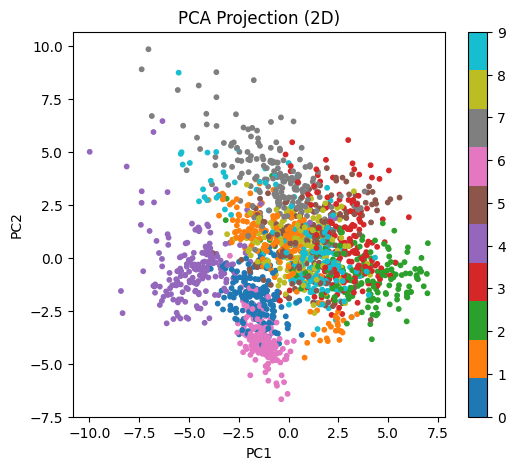

In [5]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', s=10)
plt.colorbar(scatter)
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 5. t-SNE projection (2D)
Note: t-SNE is computationally heavier.

In [6]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

### t-SNE Visualization

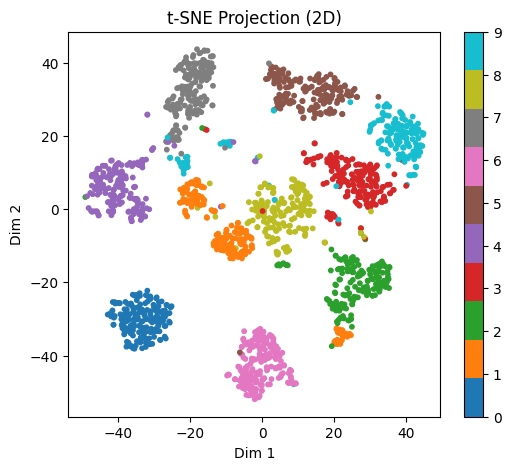

In [7]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='tab10', s=10)
plt.colorbar(scatter)
plt.title("t-SNE Projection (2D)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

## 6. PCA vs t-SNE summary comparison
* PCA: linear, preserves global variance
* t-SNE: nonlinear, preserves local neighborhoods
* PCA is deterministic and fast
* t-SNE is stochastic and slower

## 7. Try on Iris dataset

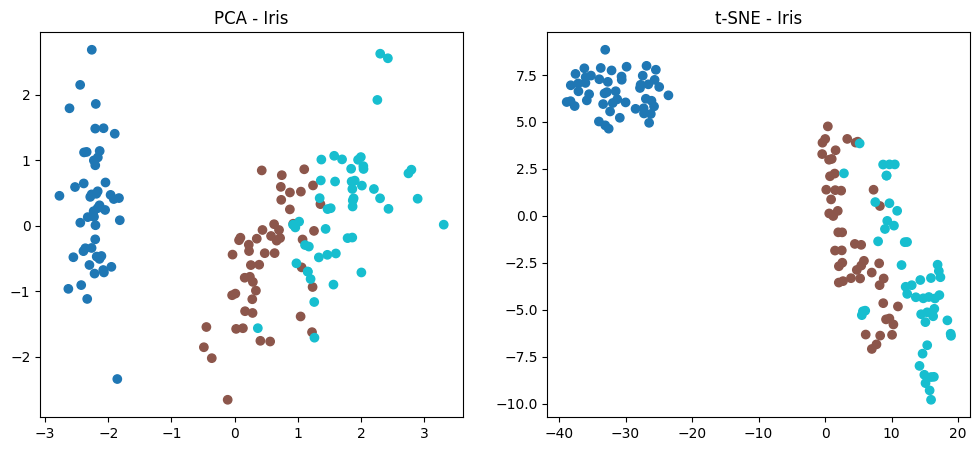

In [8]:
iris = load_iris()
X2 = iris.data
y2 = iris.target

X2_scaled = StandardScaler().fit_transform(X2)

X2_pca = PCA(n_components=2).fit_transform(X2_scaled)
X2_tsne = TSNE(n_components=2, perplexity=20, random_state=42).fit_transform(X2_scaled)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X2_pca[:,0], X2_pca[:,1], c=y2, cmap='tab10')
plt.title("PCA - Iris")

plt.subplot(1,2,2)
plt.scatter(X2_tsne[:,0], X2_tsne[:,1], c=y2, cmap='tab10')
plt.title("t-SNE - Iris")

plt.show()


## 8. From-scratch t-SNE (toy, NumPy only)

We will implement a minimal version of t-SNE to understand how it works internally.

This implementation is **not optimized for performance** and is intended only for educational purposes.
It works well for small datasets (typically ≤ 200 points).

All steps are heavily commented to make the intuition explicit.

---

### 8.1 Why we need `compute_P_perplexity` and `binary_search_sigma`

In t-SNE, we must define how each point measures similarity to others in high-dimensional space.

Instead of using a single fixed Gaussian bandwidth (σ), we:

* assign **a different σᵢ for each point**
* ensure each point has a similar “effective neighborhood size”

This is done using the concept of **perplexity**, which controls:

> how many neighbors each point considers relevant

To achieve a fixed perplexity (e.g., 30), we must solve:

* find σᵢ such that the entropy of the neighborhood distribution matches the target

Since there is no closed-form solution, we use:

* **binary search over σᵢ**
* to match a desired perplexity value

This step is crucial because it makes t-SNE **adaptive to local density**:
dense regions get small σ, sparse regions get large σ.

---

### 8.2 `binary_search_sigma` and `compute_P_perplexity` implementation

Below are the helper functions used to compute:

* entropy
* perplexity
* per-point σᵢ via binary search
* full conditional probability matrix P

In [61]:
import numpy as np


def compute_entropy(P_row):
    # Shannon entropy of a probability distribution
    #
    # H(P) = - Σ p_i log2(p_i)
    #
    # Interpretation:
    # - measures how "spread out" the distribution is
    # - low entropy → one dominant neighbor
    # - high entropy → many equally likely neighbors

    # Remove near-zero probabilities for numerical stability
    # (log(0) is undefined and unstable in computation)
    P_row = P_row[P_row > 1e-12]

    # Compute Shannon entropy in bits (log base 2)
    return -np.sum(P_row * np.log2(P_row))


def perplexity(P_row):
    # Perplexity is defined as:
    #
    # Perp(P) = 2 ^ H(P)
    #
    # where H(P) is Shannon entropy
    #
    # Intuition:
    # - perplexity ≈ "effective number of neighbors"
    # - if perplexity = 30 → distribution behaves like it has ~30 equal neighbors
    #
    # This connects information theory (entropy)
    # with geometric neighborhood size in t-SNE.

    return 2 ** compute_entropy(P_row)


def binary_search_sigma(D_i, target_perplexity=30.0, tol=1e-5, max_iter=50):

    # We want to find sigma_i such that:
    #
    # perplexity(P_i(sigma_i)) ≈ target_perplexity
    #
    # This ensures each point has a similar "effective neighborhood size"

    # Search range for sigma:
    # - small sigma → very sharp distribution (few neighbors)
    # - large sigma → very flat distribution (many neighbors)
    sigma_min, sigma_max = 1e-5, 100.0

    for _ in range(max_iter):

        # Midpoint of current search interval
        sigma = (sigma_min + sigma_max) / 2

        # ---------------------------------------------------------
        # Step 1: build Gaussian similarity distribution for point i
        #
        # p_j|i ∝ exp(-||x_i - x_j||^2 / (2σ^2))
        #
        # Interpretation:
        # - small distances → high similarity
        # - large distances → near zero similarity
        # ---------------------------------------------------------
        P_i = np.exp(-D_i / (2 * sigma ** 2))

        # Numerical stability: remove extremely small values
        # (they contribute nothing but can break normalization)
        P_i[P_i < 1e-12] = 0.0

        # Normalize into probability distribution
        # so that Σ_j p_j|i = 1
        P_i = P_i / (np.sum(P_i) + 1e-12)

        # Compute current effective neighborhood size
        perp = perplexity(P_i)

        # ---------------------------------------------------------
        # Binary search logic:
        #
        # If perplexity is too HIGH:
        # → distribution is too flat
        # → sigma is too large
        # → reduce sigma
        #
        # If perplexity is too LOW:
        # → distribution is too sharp
        # → sigma is too small
        # → increase sigma
        # ---------------------------------------------------------
        if perp > target_perplexity:
            sigma_max = sigma
        else:
            sigma_min = sigma

        # Stop early if close enough
        if abs(perp - target_perplexity) < tol:
            break

    # Return:
    # - optimal sigma_i for this point
    # - its conditional probability distribution P_i
    return sigma, P_i


def compute_P_perplexity(D, target_perplexity=30.0):

    # D is full pairwise squared distance matrix:
    # D[i, j] = ||x_i - x_j||^2

    N = D.shape[0]

    # Final conditional probability matrix:
    # P[i, j] = p(j | i)
    P = np.zeros((N, N))

    # Store per-point bandwidths σ_i
    sigmas = np.zeros(N)

    # ---------------------------------------------------------
    # For each point i:
    # - find its own sigma_i via binary search
    # - compute its local probability distribution P_i
    # ---------------------------------------------------------
    for i in range(N):

        sigma_i, P_i = binary_search_sigma(D[i], target_perplexity)

        P[i] = P_i
        sigmas[i] = sigma_i

    # Force p_{i|i} = 0
    np.fill_diagonal(P, 0.0)

    return P, sigmas

### 8.3 Implementation components
**We need next building blocks:**
* pairwise distances in high-dimensional space
* conditional probabilities (Gaussian similarities)
* perplexity-based adaptive bandwidths (σᵢ)
* symmetric joint probability matrix P
* low-dimensional Student-t similarities Q
* KL divergence objective
* gradient-based optimization with momentum and adaptive gains

This section implements the full optimization loop that gradually transforms random 2D points into a structure that reflects the original high-dimensional geometry.

---

**Key idea of the algorithm**

t-SNE minimizes:

> mismatch between high-dimensional similarities (P) and low-dimensional similarities (Q)

Formally:

* P = “what the data says”
* Q = “what the embedding currently shows”

The optimization tries to make:

> Q ≈ P

so that local neighborhoods are preserved in 2D.


Below are all helper functions and the final optimization procedure.

---

### 8.4 Pairwise distances

We first compute squared Euclidean distances between all points.


In [10]:
def pairwise_squared_distances(X):
    """
    Compute full matrix of squared Euclidean distances between all pairs of rows in X.

    For vectors a and b:
        ||a - b||^2 = ||a||^2 + ||b||^2 - 2 * a·b

    Parameters
    ----------
    X : ndarray of shape (N, d)
        N points in d-dimensional space.

    Returns
    -------
    D : ndarray of shape (N, N)
        Matrix where D[i, j] = squared distance between X[i] and X[j].
    """

    # Step 1: compute squared norms for every point ||x_i||^2
    # Result shape: (N,)
    sum_X = np.sum(np.square(X), axis=1)

    # Step 2: use broadcasting to build ||x_i||^2 + ||x_j||^2 for all pairs (i, j)
    # sum_X[:, None] -> (N, 1)
    # sum_X[None, :] -> (1, N)
    # Adding them gives an (N, N) matrix

    # Step 3: subtract 2 * dot products x_i · x_j for all pairs
    # X.dot(X.T) gives all pairwise dot products (N, N)
    D = sum_X[:, None] + sum_X[None, :] - 2 * X.dot(X.T)

    # Step 4: numerical safety — distances of points to themselves must be 0
    np.fill_diagonal(D, 0.0)

    return D


---

### 8.5 Conditional probabilities (local neighborhoods)

We convert distances into Gaussian similarities:

* closer points → higher probability
* farther points → near zero probability

> Note: this function is not used in final version of tsne but kept only for historical and learning purposes. `compute_P_perplexity` used in final version

In [11]:
def compute_conditional_P(D, sigma):
    """
    Compute conditional neighbor probabilities p_{j|i} from squared distances.

    For each point i, we place a Gaussian centered at i and measure how
    likely every other point j is to be its neighbor:

        p_{j|i} = exp( -D[i,j] / (2*sigma^2) )
                  ---------------------------------
                  sum_{k != i} exp( -D[i,k] / (2*sigma^2) )

    This is done row-wise, so each row of P is a probability distribution
    that sums to 1.

    Parameters
    ----------
    D : ndarray of shape (N, N)
        Squared distance matrix where D[i, j] = ||x_i - x_j||^2.

    sigma : float
        Gaussian bandwidth (neighborhood size). In real t-SNE this is
        different for every point and found via perplexity search.

    Returns
    -------
    P : ndarray of shape (N, N)
        Conditional probability matrix where P[i, j] = p_{j|i}.
    """

    # Step 1: convert distances into Gaussian similarities
    # Small distance -> value close to 1
    # Large distance -> value close to 0
    P = np.exp(-D / (2 * sigma**2))

    # Step 2: a point cannot be its own neighbor
    # Force p_{i|i} = 0
    np.fill_diagonal(P, 0.0)

    # Step 3: normalize each row so it becomes a probability distribution
    # Each row now sums to 1: sum_j p_{j|i} = 1
    P = P / (np.sum(P, axis=1, keepdims=True) + 1e-12)

    return P


---

### 8.6 Symmetrization (important conceptual step)

We convert directional probabilities into a joint distribution:

> P_{ij} = p_{j|i} + p_{i|j}

This makes the similarity matrix symmetric and comparable to Q.


In [12]:

def symmetrize_P(P):
    """
    Convert conditional probabilities p_{j|i} into a symmetric joint probability P_{ij}.

    After compute_conditional_P, each row P[i, :] represents:
        p_{j|i} = probability that point j is a neighbor of i.

    However, this is asymmetric because each point i has its own local normalization.

    To make a proper joint probability over pairs (i, j), we symmetrize:

        P_{ij} = p_{j|i} + p_{i|j}

    Then we normalize so that all probabilities sum to 1.

    Parameters
    ----------
    P : ndarray of shape (N, N)
        Conditional probability matrix p_{j|i}.

    Returns
    -------
    P_sym : ndarray of shape (N, N)
        Symmetric joint probability matrix P_{ij}.
    """

    # Step 1: combine directional probabilities
    # If either i considers j a neighbor OR j considers i a neighbor,
    # we increase the strength of that relationship.
    P_sym = (P + P.T)

    # Step 2: normalize to form a valid probability distribution over all pairs
    # Ensures sum_{i,j} P_{ij} = 1
    P_sym /= np.sum(P_sym)

    return P_sym


---

### 8.7 Low-dimensional similarities (Student-t kernel)

We compute similarities in the embedding space:

* uses heavy-tailed Student-t distribution
* prevents crowding problem


In [13]:
def student_t_Q(Y):
    """
    Compute low-dimensional similarities Q_{ij} using a Student-t kernel.

    This defines how similar points LOOK in the current embedding Y.

    Unlike P (fixed from data), Q changes at every iteration.

    We use a heavy-tailed Student-t distribution:
        Q_{ij} ∝ 1 / (1 + ||y_i - y_j||^2)

    This avoids the "crowding problem" by ensuring distant points
    still exert repulsive force.

    Returns both:
    - Q: normalized probability distribution over pairs
    - Q_num: unnormalized kernel used for gradient computation
    """

    # Step 1: compute pairwise squared distances in embedding space
    # This measures how far points are in the current 2D map
    D = pairwise_squared_distances(Y)

    # Step 2: Student-t kernel (heavy-tailed similarity)
    # Close points -> large value
    # Far points -> slowly decaying value (important for repulsion)
    Q_num = 1.0 / (1.0 + D)

    # Step 3: remove self-similarity (a point is not similar to itself)
    np.fill_diagonal(Q_num, 0.0)

    # Step 4: normalize into a probability distribution over all pairs
    # Now sum_{i,j} Q_{ij} = 1
    Q = Q_num / (np.sum(Q_num) + 1e-12)

    return Q, Q_num


---

### 8.8 KL divergence objective

We measure how different P and Q are:


In [14]:
def kl_divergence(P, Q):
    """
    Compute KL divergence KL(P || Q) between two probability distributions over pairs.

    In t-SNE:
    - P = target similarities (from high-dimensional space)
    - Q = current similarities (from embedding)

    We measure how well Q matches P.

    KL(P || Q) = sum_{i,j} P_ij * log(P_ij / Q_ij)

    Interpretation:
    - If Q underestimates a high P_ij -> large penalty
    - If Q matches P -> small contribution
    - If P_ij is small -> almost no effect

    This is asymmetric: it penalizes missing neighbors more than extra ones.
    """
    return np.sum(P * np.log((P + 1e-12) / (Q + 1e-12)))



---

### 8.9 Full t-SNE optimization loop

This is the main algorithm that learns the embedding.

It includes:

* perplexity-based P construction
* gradient computation
* adaptive gains
* momentum scheduling
* iterative optimization


In [177]:

def tsne_toy(
    X,
    sigma=1.0,  # deprecated V1
    dim=2,
    lr=200.0,
    n_iter=500,
    seed=42,
    target_perplexity=30.0, # optimal default value
    initial_momentum=None,
    final_momentum=None,
    verbose=True,
    verbose_on_iter=100,
    show_pq_matrix_training=False,
):
    rng = np.random.default_rng(seed)
    N = X.shape[0]

    # High-dim similarities
    D_high = pairwise_squared_distances(X)

    # V1 first version was with global sigma value and not point specific - it didn't work well
    # P_cond = compute_conditional_P(D_high, sigma)

    # V2 this is second version
    P_cond, sigmas = compute_P_perplexity(D_high, target_perplexity=target_perplexity)
    P = symmetrize_P(P_cond)

    # Initialize Y randomly
    Y = 1e-4 * rng.standard_normal((N, dim))

    # V3 Momentum and adaptive gains added in version 3
    Y_inc = np.zeros_like(Y)      # previous update (velocity)
    grads_memory = np.zeros_like(Y)      # previous update (velocity)
    gains = np.ones_like(Y)      # per-parameter gains
    eta = lr

    if final_momentum is None and initial_momentum is not None:
        final_momentum = initial_momentum

    # for better visualizations
    if show_pq_matrix_training:
        Q_init, _ = student_t_Q(Y)
        max_error_ref = np.max(np.abs(P - Q_init))
        
    for it in range(n_iter):
        Q, Q_num = student_t_Q(Y)

        # Gradient
        grads = np.zeros_like(Y)
        for i in range(N):
            # Vector from all points j -> point i
            # diff[j] = y_i - y_j
            # This gives direction of interaction between i and every other point
            diff = Y[i] - Y  # shape: (N, 2)

            # Error signal for each pair (i, j)
            # P[i,j] = how close they SHOULD be (from high-dimensional space)
            # Q[i,j] = how close they ARE in current embedding
            # If positive -> attraction (too far apart)
            # If negative -> repulsion (too close)
            coeff = (P[i] - Q[i]) * Q_num[i]  # shape: (N,)
            # WHY multiply by Q_num[i]?
            # --------------------------------
            # Q_num[i, j] = 1 / (1 + ||y_i - y_j||^2)
            # It is the unnormalized Student-t similarity in low-dimensional space.
            #
            # Intuition:
            # - If points i and j are close in embedding -> Q_num is large -> stronger force
            # - If points are far apart -> Q_num is small -> weaker influence
            #
            # So this term acts like a distance-based weighting of the error signal.
            # It ensures that only reasonably close points strongly affect each other,
            # while distant points still contribute weakly (preventing collapse).
            #
            # In short:
            # (P - Q) decides *direction* (attract vs repel)
            # Q_num decides *strength* based on distance in 2D space


            # Convert scalar strengths into vector forces
            # coeff[:, None] scales each direction vector diff[j]
            # This creates force contribution of each j on i
            pairwise_forces = (coeff[:, None]) * diff  # shape: (N, 2)

            # Sum all pairwise forces acting on point i
            # This gives total force (gradient) for point i
            # 4 comes from derivative chain rule applied to ||yi-yj||^2
            grads[i] = 4.0 * np.sum(pairwise_forces, axis=0)

        # Update positions of all points in embedding space
        # Move each point slightly in direction of gradient
        # This reduces KL divergence between P and Q
        if initial_momentum is None:
            # simple update flow with constant global learning rate value for all points
            Y -= lr * grads
        else:
            # --- Adaptive gains update (per-coordinate learning rates) ---
            # We keep a "gain" for every coordinate of every point (same shape as Y).
            # The gain scales the learning rate locally for that coordinate.
            #
            # Idea:
            # - If the gradient direction FLIPS compared to the previous step,
            #   we likely overshot the minimum along this coordinate → increase gain
            #   so the optimizer reacts more strongly next step.
            # - If the gradient direction stays the SAME, we are moving steadily
            #   downhill → slightly decrease gain for finer control.
            prev_grads = grads_memory
            sign_change = np.sign(grads) != np.sign(prev_grads)
            grads_memory = grads
            # Increase gain where sign changed (+0.2),
            # decrease gain where sign stayed the same (*0.8)
            gains = (gains + 0.2) * sign_change + (gains * 0.8) * (~sign_change)
            # Prevent gains from becoming too small (freezing) or too large (exploding)
            gains = np.clip(gains, 0.01, 100)

            # ----- Momentum schedule -----
            momentum = initial_momentum if it < 250 else final_momentum

            # ----- Update with momentum -----
            Y_inc = momentum * Y_inc + eta * (gains * grads)
            Y -= Y_inc

        # verbose and pq_matrix during training for experimenting and learning purposes
        if verbose and (it + 1) % verbose_on_iter == 0:
            loss = kl_divergence(P, Q)
            print(f"iter {it+1:4d} | KL={loss:.6f}")

            if show_pq_matrix_training:

                vmax = np.percentile(np.concatenate([P.flatten(), Q.flatten()]), 99)

                # print(np.diag(P)[:10])
                plt.figure(figsize=(8, 2))
                # P matrix (fixed)
                plt.subplot(1, 3, 1)
                plt.title("P (high-dim similarities)")
                plt.imshow(P, cmap="viridis", vmin=0, vmax=vmax)
                plt.colorbar()

                # Q matrix (evolving)
                plt.subplot(1, 3, 2)
                plt.title("Q (low-dim similarities)")
                plt.imshow(Q, cmap="viridis", vmin=0, vmax=vmax)
                plt.colorbar()

                # |P - Q| mismatch
                plt.subplot(1, 3, 3)
                plt.title("|P - Q| mismatch")
                plt.imshow(np.abs(P - Q), cmap="hot", vmin=0, vmax=max_error_ref)
                plt.colorbar()

                plt.tight_layout()
                plt.show()

    return Y, P


---

### 8.10 Implementation review

At this point, implementation includes:

* full t-SNE pipeline
* perplexity-based adaptive neighborhoods
* symmetric probability model
* Student-t embedding space
* KL divergence objective
* momentum + adaptive gains optimizer
* visualization hooks for debugging

---


## 9. Iris dataset - smoke test & experiments

Now we test our from-scratch t-SNE implementation on a real dataset.

We start with the Iris dataset, which is small (150 samples) and low-dimensional (4 features), making it ideal for debugging and sanity checks.

### 9.1 First run t-SNE from scratch

In [178]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()

# Standardize features to zero mean and unit variance
X_iris = StandardScaler().fit_transform(iris.data)

# Class labels (for visualization only, NOT used in t-SNE)
y_iris = iris.target

# full dataset (150 points)
N = X_iris.shape[0]

In [179]:
print('Experiment 1:\n')
Y_toy_iris_1, P_toy_iris_1 = tsne_toy(X_iris, lr=20.0, n_iter=8000, verbose_on_iter=1000)
print('Experiment 2:\n')
Y_toy_iris_2, P_toy_iris_2 = tsne_toy(X_iris, lr=40.0, n_iter=800, verbose_on_iter=100)

Experiment 1:

iter 1000 | KL=0.174845
iter 2000 | KL=0.162054
iter 3000 | KL=0.156795
iter 4000 | KL=0.153777
iter 5000 | KL=0.151766
iter 6000 | KL=0.150306
iter 7000 | KL=0.149184
iter 8000 | KL=0.148286
Experiment 2:

iter  100 | KL=0.247991
iter  200 | KL=0.204716
iter  300 | KL=0.189085
iter  400 | KL=0.180490
iter  500 | KL=0.174927
iter  600 | KL=0.170969
iter  700 | KL=0.167976
iter  800 | KL=0.165615


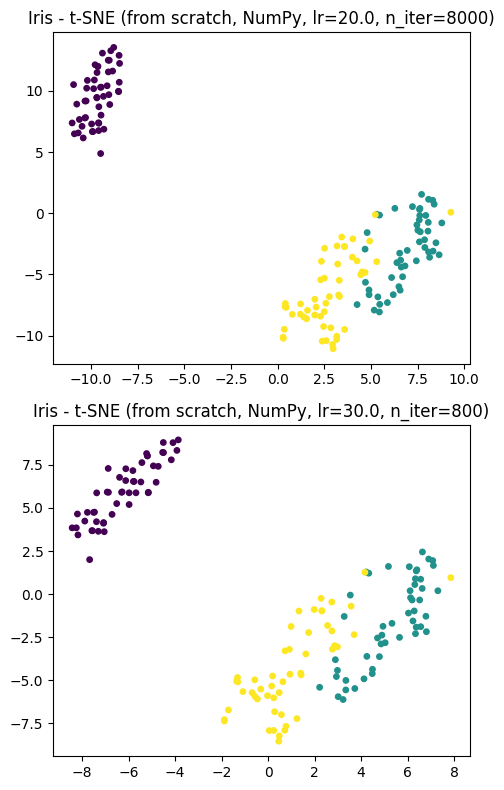

In [180]:
import matplotlib.pyplot as plt

# Side-by-side visualization
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

axes[0].scatter(Y_toy_iris_1[:, 0], Y_toy_iris_1[:, 1], c=y_iris, s=15)
axes[0].set_title("Iris - t-SNE (from scratch, NumPy, lr=20.0, n_iter=8000)")

axes[1].scatter(Y_toy_iris_2[:, 0], Y_toy_iris_2[:, 1], c=y_iris, s=15)
axes[1].set_title("Iris - t-SNE (from scratch, NumPy, lr=30.0, n_iter=800)")

plt.tight_layout()
plt.show()

### 9.2 t-SNE with momentum - Iris experiment

Now we run the same t-SNE implementation with momentum enabled.

Momentum introduces inertia in the optimization process, meaning that updates are influenced not only by the current gradient but also by previous updates.

This can help:
* smooth noisy updates
* accelerate convergence in complex landscapes
* reduce oscillations in high-dimensional optimization

In [181]:
# now the same with momentum
Y_toy_iris_momentum, P_toy_iris_momentum = tsne_toy(X_iris, sigma=1.5, lr=30.0, n_iter=8000, initial_momentum=1, final_momentum=1, verbose_on_iter=1000)

iter 1000 | KL=0.307145
iter 2000 | KL=0.298686
iter 3000 | KL=0.294744
iter 4000 | KL=0.291959
iter 5000 | KL=0.290342
iter 6000 | KL=0.288682
iter 7000 | KL=0.287524
iter 8000 | KL=0.286485


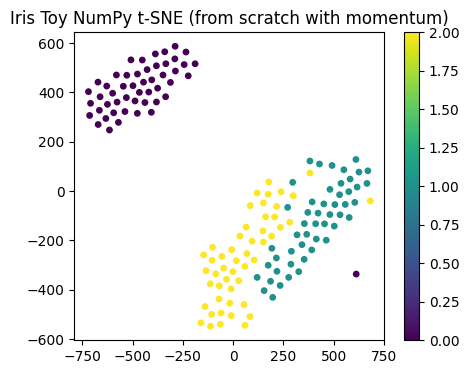

In [182]:
plt.figure(figsize=(5,4))
sc = plt.scatter(Y_toy_iris_momentum[:,0], Y_toy_iris_momentum[:,1], c=y_iris, s=15)
plt.colorbar(sc)
plt.title("Iris Toy NumPy t-SNE (from scratch with momentum)")
plt.show()

* probably momentum logic is overkill for iris dataset as it is too simple

### 9.3 Iris comparison - PCA vs t-SNE (no momentum vs momentum)

Now we compare three different 2D embeddings of the same dataset:

* PCA → linear projection (variance preservation)
* t-SNE (no momentum) → basic nonlinear neighborhood preservation
* t-SNE (with momentum) → same objective, different optimization dynamics

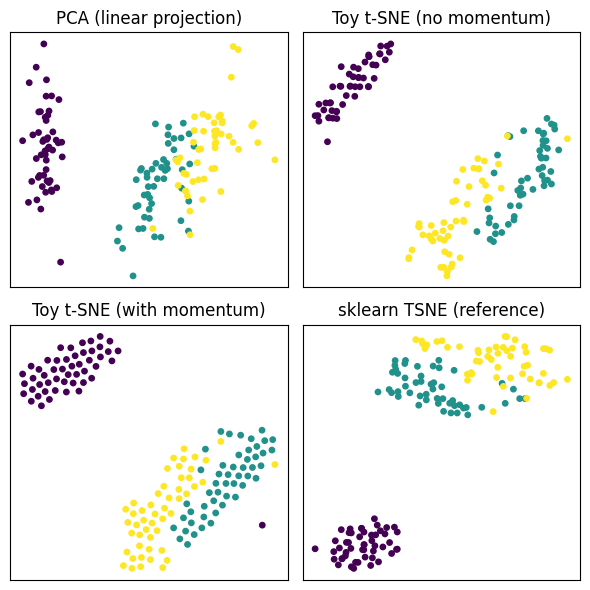

In [153]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA baseline
X_pca = PCA(n_components=2).fit_transform(X_iris)

# t-SNE (no momentum)
Y_tsne = tsne_toy(
    X_iris,
    lr=20.0,
    n_iter=1000,
    verbose=False
)[0]

# t-SNE (with momentum)
Y_tsne_m = tsne_toy(
    X_iris,
    lr=30.0,
    n_iter=8000,
    initial_momentum=1,
    final_momentum=1,
    verbose=False
)[0]

# sklearn TSNE (reference)
Y_sklearn = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=30,
    max_iter=1000,
    init="random",
    random_state=42,
).fit_transform(X_iris)


# Side-by-side visualization
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

# PCA
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, s=15)
axes[0, 0].set_title("PCA (linear projection)")
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])

# Toy t-SNE (no momentum)
axes[0, 1].scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=y_iris, s=15)
axes[0, 1].set_title("Toy t-SNE (no momentum)")
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])

# Toy t-SNE (momentum)
axes[1, 0].scatter(Y_tsne_m[:, 0], Y_tsne_m[:, 1], c=y_iris, s=15)
axes[1, 0].set_title("Toy t-SNE (with momentum)")
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

# sklearn TSNE
axes[1, 1].scatter(Y_sklearn[:, 0], Y_sklearn[:, 1], c=y_iris, s=15)
axes[1, 1].set_title("sklearn TSNE (reference)")
axes[1, 1].set_xticks([])
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

### 9.4 Experiment - effect of target perplexity

Now we study how target perplexity affects the resulting embedding

> perplexity ≈ effective number of neighbors each point considers

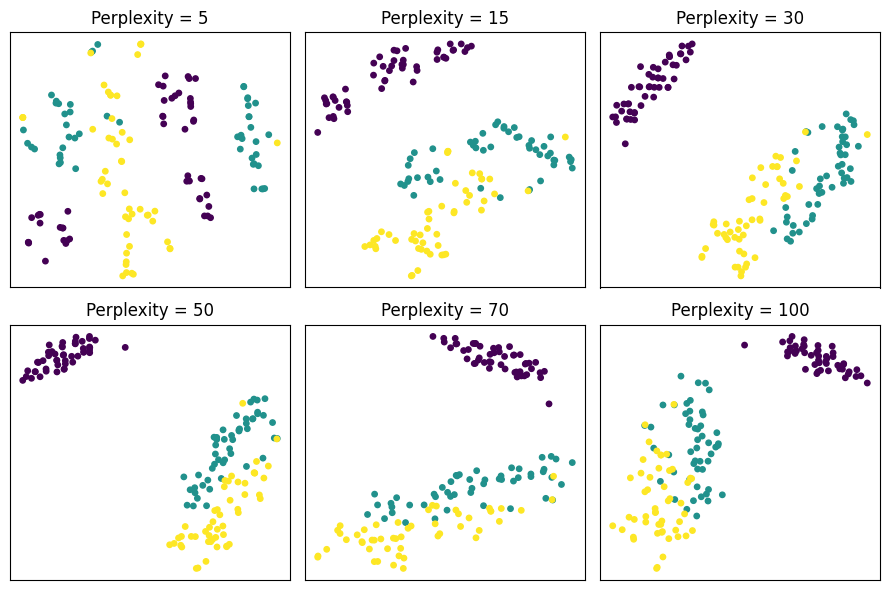

In [158]:
# Run t-SNE for multiple perplexity values
perplexities = [5, 15, 30, 50, 70, 100]

embeddings = []

for p in perplexities:
    Y_p, _ = tsne_toy(
        X_iris,
        lr=20.0,
        n_iter=800,
        target_perplexity=p,
        verbose=False
    )
    embeddings.append(Y_p)

# Visualization grid
fig, axes = plt.subplots(2, len(perplexities) // 2, figsize=(9, 6))

# axes is 2D -> make it flat list
axes = axes.ravel()

for ax, Y_p, p in zip(axes, embeddings, perplexities):
    ax.scatter(Y_p[:, 0], Y_p[:, 1], c=y_iris, s=15)
    ax.set_title(f"Perplexity = {p}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

For Iris:

* optimal range is 30-50
* below → too fragmented
* above → mihgt be too global

### 9.5 Visualizing P vs Q during training (heatmaps)

observe how:

* P matrix (high-dimensional similarities) = target structure
* Q matrix (low-dimensional similarities) = learned structure

evolve over time.

> how the model gradually “learns” the neighborhood structure

iter   20 | KL=1.511477


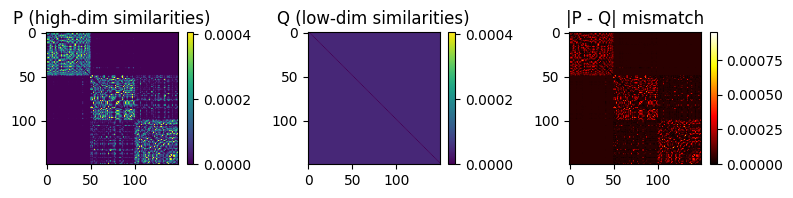

iter   40 | KL=1.196018


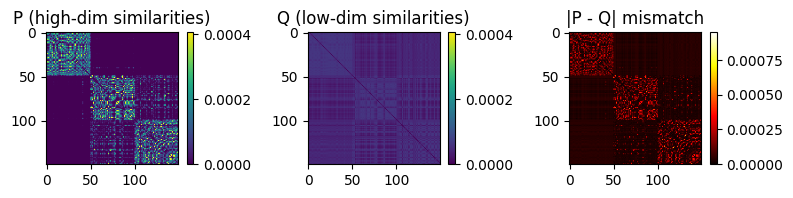

iter   60 | KL=0.622315


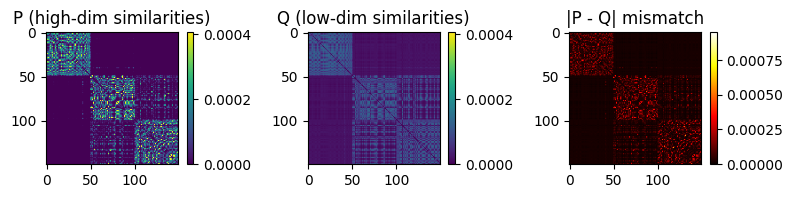

iter   80 | KL=0.483872


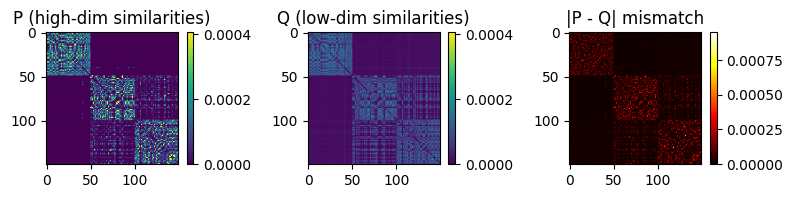

iter  100 | KL=0.402007


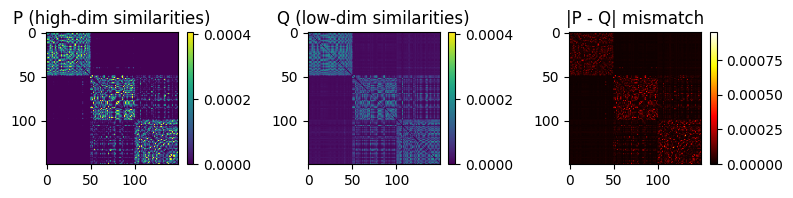

iter  120 | KL=0.352200


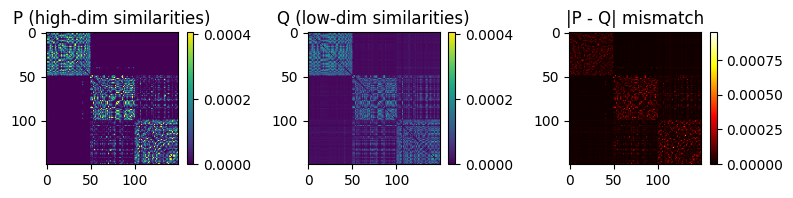

iter  140 | KL=0.322238


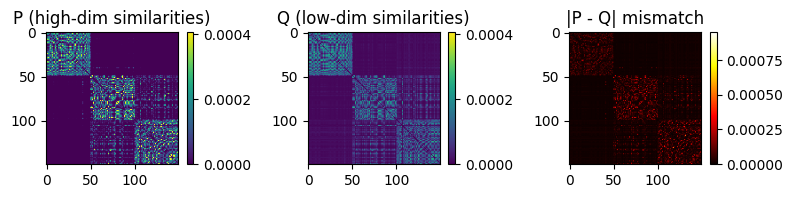

In [164]:
Y_toy_iris_pq, P_toy_iris_pq = tsne_toy(X_iris, lr=15.0, n_iter=140, verbose_on_iter=20, show_pq_matrix_training=True)

* Early iterations
    - Q is almost uniform noise
    - |P − Q| is high everywhere
* Middle iterations
    - Q starts forming weak cluster blocks
    - structure begins to emerge
    - mismatch concentrates around cluster boundaries
* Later iterations
    - Q becomes visually similar to P

### 9.6 P vs Q heatmaps - subsampled Iris

To make the similarity structure easier to interpret, we randomly select a subset of points and visualize only their pairwise relationships.

This reduces visual noise and makes block structure much more visible.

iter   10 | KL=0.436824


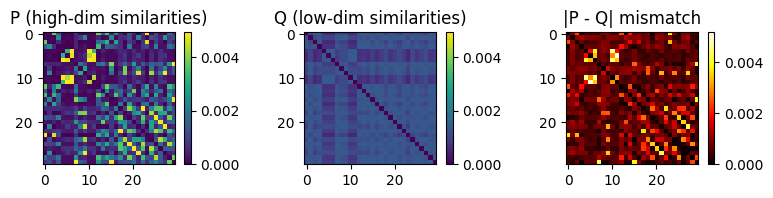

iter   20 | KL=0.095803


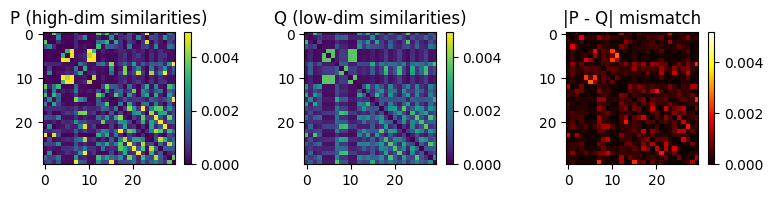

iter   30 | KL=0.070366


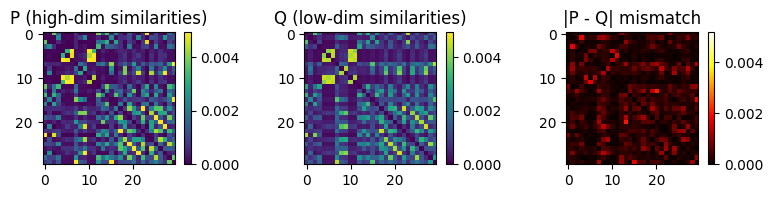

iter   40 | KL=0.062251


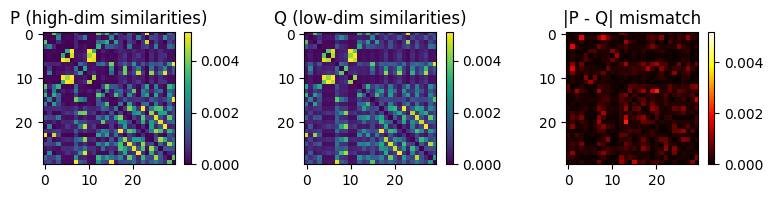

In [165]:
rng = np.random.default_rng(42)

subset_size = 30
idx = rng.choice(len(X_iris), size=subset_size, replace=False)

X_sub_iris = X_iris[idx]
y_sub_iris = y_iris[idx]

Y_sub_iris, P_sub_iris = tsne_toy(
    X_sub_iris,
    lr=20.0,
    n_iter=40,
    verbose=True,
    verbose_on_iter=10,
    show_pq_matrix_training=True,
    target_perplexity=15
)

iter   60 | KL=0.466995


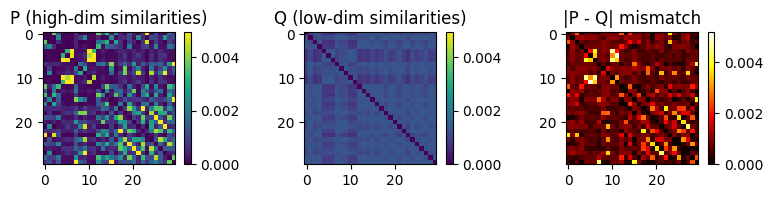

iter  120 | KL=0.286341


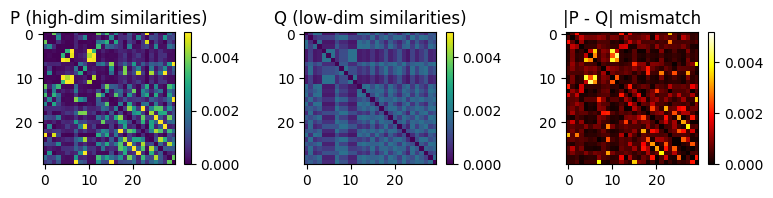

iter  180 | KL=0.214461


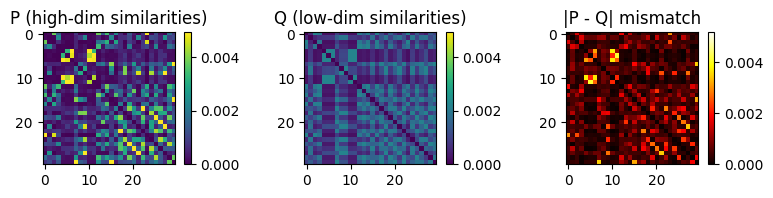

iter  240 | KL=0.173811


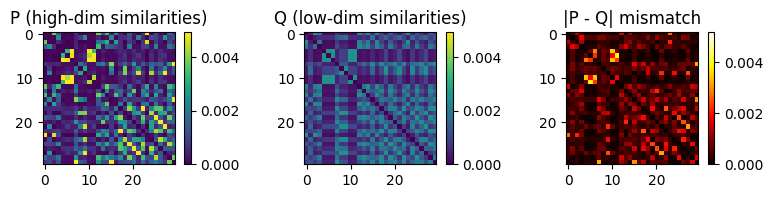

iter  300 | KL=0.141619


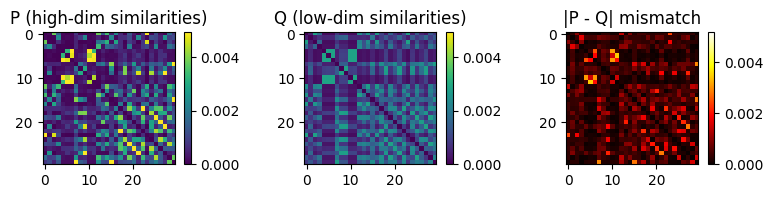

iter  360 | KL=0.118623


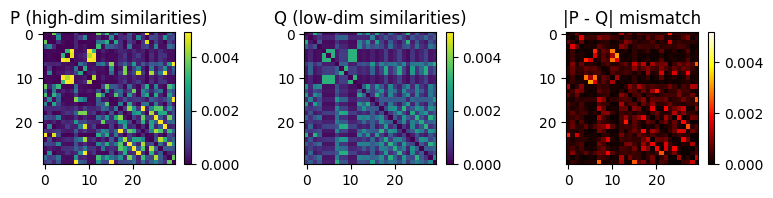

iter  420 | KL=0.103747


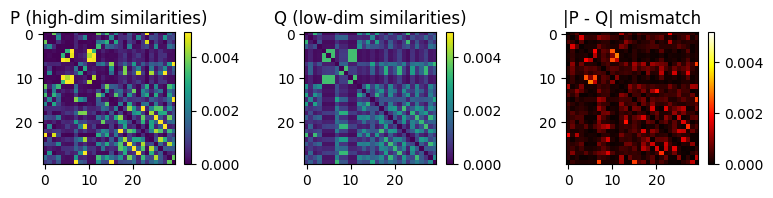

iter  480 | KL=0.093821


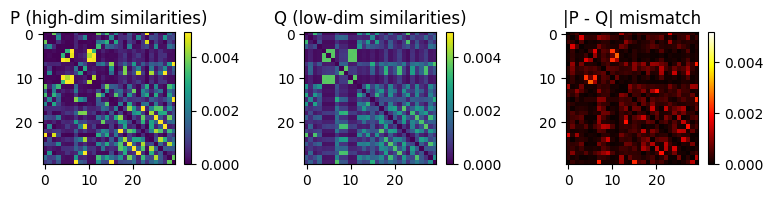

In [166]:
Y_sub_iris, P_sub_iris = tsne_toy(
    X_sub_iris,
    lr=10.0,
    n_iter=480,
    initial_momentum=0.8,
    verbose=True,
    verbose_on_iter=60,
    show_pq_matrix_training=True,
    target_perplexity=15
)

## 10 Run toy t-SNE on a small subset of Digits

In [167]:
# Run experiments
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

X_small, y_small = load_digits(return_X_y=True)
X_small = StandardScaler().fit_transform(X_small)

N = 150
X_small = X_small[:N]
y_small = y_small[:N]

print("No momentum")
Y_toy, P_toy = tsne_toy(X_small, sigma=2.0, lr=20.0, n_iter=600)

print("\nMomentum = 1")
Y_toy_m_1, _ = tsne_toy(
    X_small, sigma=2.0, lr=40.0, n_iter=1200,
    initial_momentum=1, final_momentum=1,
    verbose_on_iter=200
)

print("\nMomentum = 0.95 → 0.9")
Y_toy_m_09, _ = tsne_toy(
    X_small, sigma=2.0, lr=40.0, n_iter=1800,
    initial_momentum=0.95, final_momentum=0.9,
    verbose_on_iter=300
)


No momentum
iter  100 | KL=0.309724
iter  200 | KL=0.228796
iter  300 | KL=0.205833
iter  400 | KL=0.195322
iter  500 | KL=0.189546
iter  600 | KL=0.186031

Momentum = 1
iter  200 | KL=0.298684
iter  400 | KL=0.303621
iter  600 | KL=0.299370
iter  800 | KL=0.297788
iter 1000 | KL=0.295661
iter 1200 | KL=0.293759

Momentum = 0.95 → 0.9
iter  300 | KL=0.312313
iter  600 | KL=0.271428
iter  900 | KL=0.252219
iter 1200 | KL=0.241450
iter 1500 | KL=0.234809
iter 1800 | KL=0.230302


### 10.1 Visualize digits result

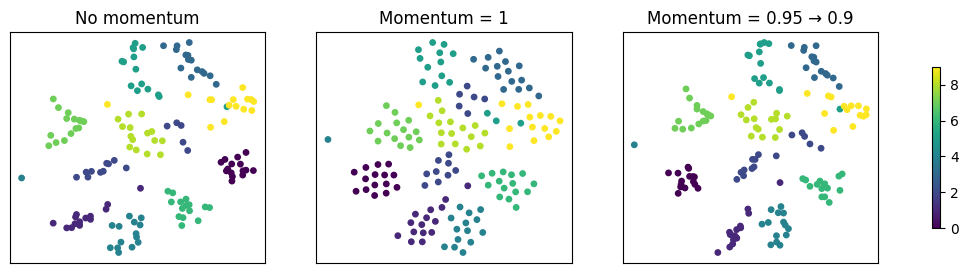

In [175]:
# Side-by-side visualization

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

embeddings = [
    (Y_toy, "No momentum"),
    (Y_toy_m_1, "Momentum = 1"),
    (Y_toy_m_09, "Momentum = 0.95 → 0.9")
]

for ax, (Y, title) in zip(axes, embeddings):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=y_small, s=15)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.colorbar(sc, ax=axes, shrink=0.7)
# plt.tight_layout()
plt.show()

### 10.2 PCA vs. t-SNE for digits

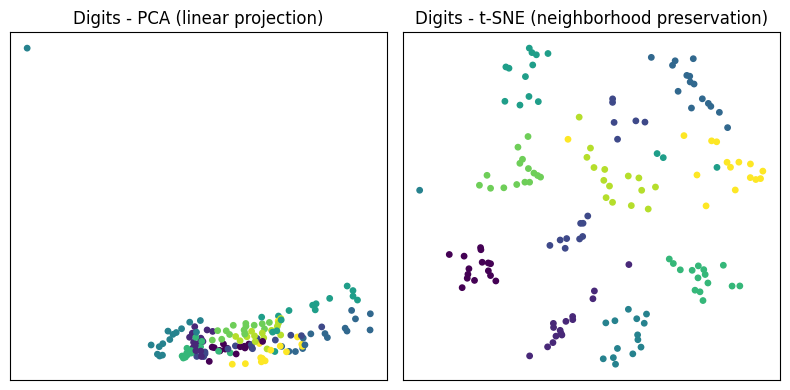

In [172]:
from sklearn.decomposition import PCA

# Compute PCA embedding
X_pca = PCA(n_components=2).fit_transform(X_small)

# Run t-SNE
Y_tsne, _ = tsne_toy(
    X_small,
    sigma=2.0,
    lr=20.0,
    n_iter=600,
    initial_momentum=0.99,
    final_momentum=0.96,
    verbose=False
)

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# PCA plot
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_small, s=15)
axes[0].set_title("Digits - PCA (linear projection)")
axes[0].set_xticks([])
axes[0].set_yticks([])

# t-SNE plot
axes[1].scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=y_small, s=15)
axes[1].set_title("Digits - t-SNE (neighborhood preservation)")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

### 10.3 Visualizing P vs Q during training for digits

iter   30 | KL=0.748923


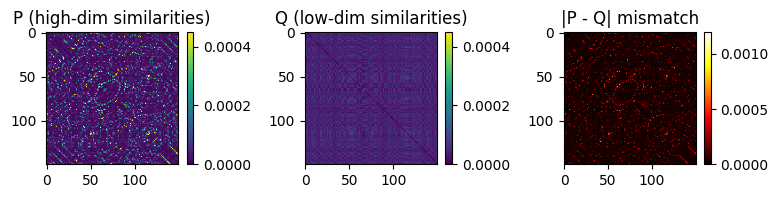

iter   60 | KL=0.339396


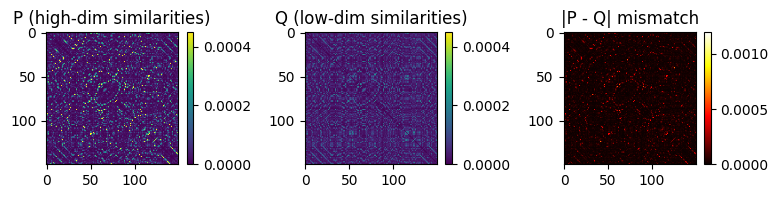

iter   90 | KL=0.268719


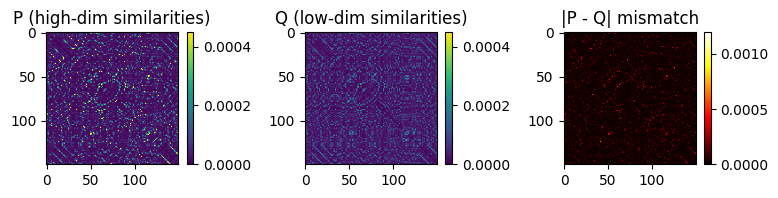

iter  120 | KL=0.239088


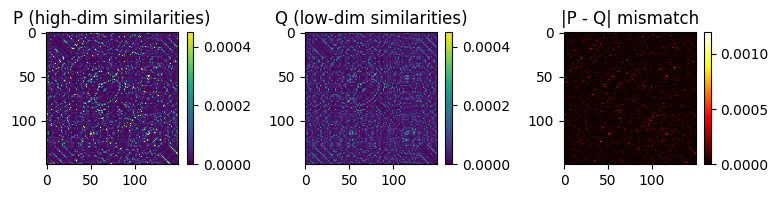

iter  150 | KL=0.222700


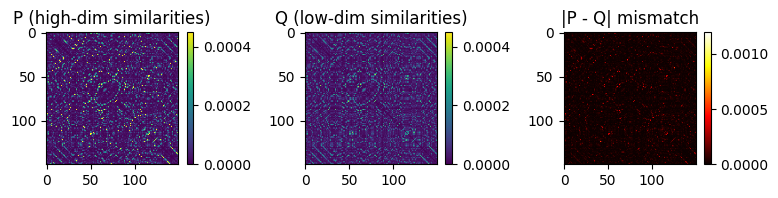

In [176]:
Y_toy, P_toy = tsne_toy(X_small, lr=30.0, n_iter=150, verbose_on_iter=30, show_pq_matrix_training=True)

## 11. 3D Examples

### 11.1 Iris - Simple one

In [183]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

Y_3d, _ = tsne_toy(
    X_iris,
    lr=20.0,
    n_iter=1200,
    dim=3,
    verbose=False
)

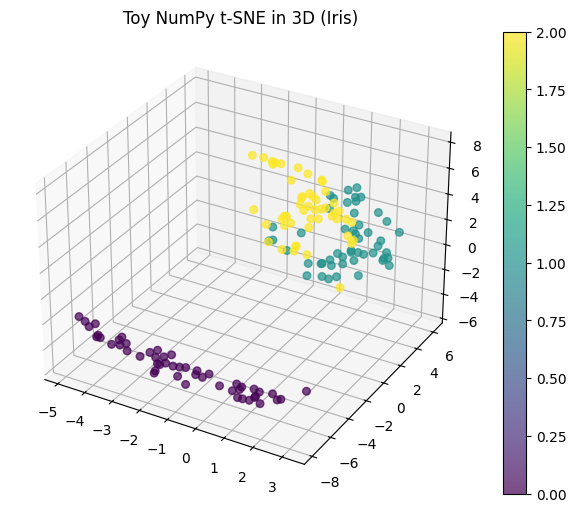

In [185]:
# 3D visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(
    Y_3d[:, 0],
    Y_3d[:, 1],
    Y_3d[:, 2],
    c=y_iris,
    s=30,
    alpha=0.7
)

ax.set_title("Toy NumPy t-SNE in 3D (Iris)")
fig.colorbar(sc)
plt.show()

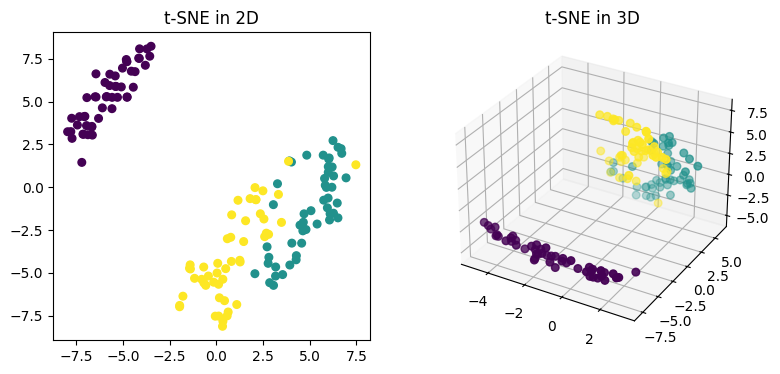

In [188]:
Y_2d, _ = tsne_toy(X_iris, lr=20.0, n_iter=1200, dim=2, verbose=False)

fig = plt.figure(figsize=(9, 4))

ax1 = fig.add_subplot(121)
ax1.scatter(Y_2d[:, 0], Y_2d[:, 1], c=y_iris, s=30)
ax1.set_title("t-SNE in 2D")

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(Y_3d[:, 0], Y_3d[:, 1], Y_3d[:, 2], c=y_iris, s=30)
ax2.set_title("t-SNE in 3D")

plt.show()

### 11.2 Digits subset

In [189]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import numpy as np

X_digits, y_digits = load_digits(return_X_y=True)
X_digits = StandardScaler().fit_transform(X_digits)

# keep it small for toy t-SNE
N = 150
X_small = X_digits[:N]
y_small = y_digits[:N]

In [ ]:
# run 2D and 3D t-SNE
Y_2d, _ = tsne_toy(
    X_small,
    lr=20.0,
    n_iter=1200,
    dim=2,
    verbose=False
)

Y_3d, _ = tsne_toy(
    X_small,
    lr=20.0,
    n_iter=1200,
    dim=3,
    verbose=False
)

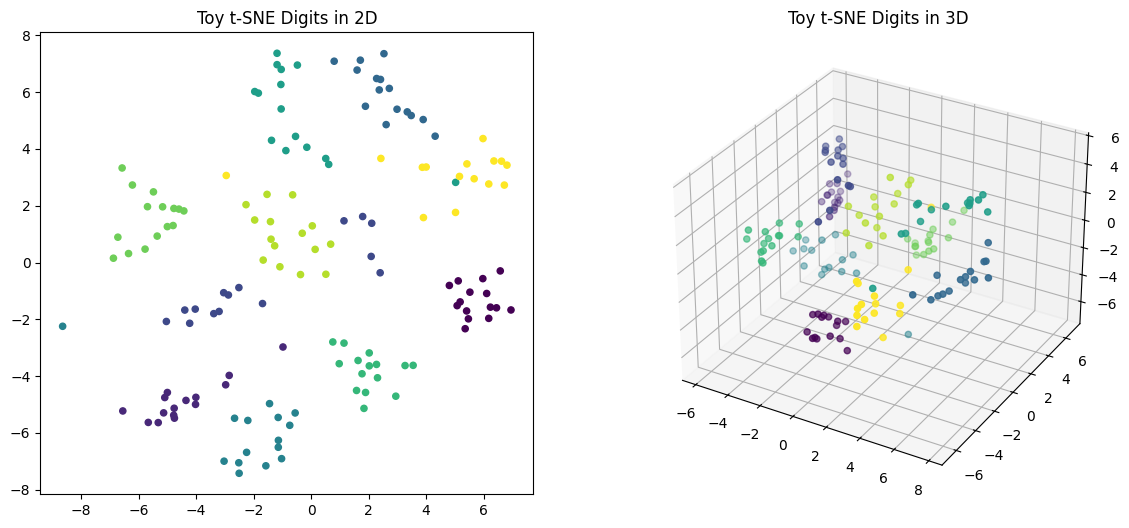

In [191]:
# visualize side-by-side
fig = plt.figure(figsize=(14, 6))

# --- 2D ---
ax1 = fig.add_subplot(121)
sc1 = ax1.scatter(Y_2d[:, 0], Y_2d[:, 1], c=y_small, s=20)
ax1.set_title("Toy t-SNE Digits in 2D")

# --- 3D ---
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(
    Y_3d[:, 0],
    Y_3d[:, 1],
    Y_3d[:, 2],
    c=y_small,
    s=20
)
ax2.set_title("Toy t-SNE Digits in 3D")

plt.show()